In [1]:
# cell 1 - imports
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
from scipy.special import logsumexp as scipy_logsumexp
import matplotlib.animation as animation
from IPython.display import HTML
import os
os.makedirs("frames", exist_ok=True)

In [2]:
# cell 2 - load mnist
mnist = datasets.MNIST(root = './data', train=True, download=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.87MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.6MB/s]


In [3]:
# cell 3 inspect raw structure
print(mnist)
print(type(mnist))

print(f"\ndataset size: {len(mnist)}")
print(f"image size: {mnist[0][0].size}") # size of a single image
print(f"label: {mnist[0][1]}")

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
<class 'torchvision.datasets.mnist.MNIST'>

dataset size: 60000
image size: (28, 28)
label: 5


In [4]:
# cell 4 - select one digit '3' and one digit '8', take first occurrence of each
labels = np.array([label for _, label in mnist]) # extracts all labels from the dataset and stores them in a numpy array

idx_3 = np.where(labels == 3)[0][0] # finds all indices where the label is 3 and selects the first one
idx_8 = np.where(labels == 8)[0][0] # finds all indices where the label is 8 and selects the first one

# shape (28, 28)
img_3 = np.array(mnist[idx_3][0], dtype=np.float64) ; # converts the '3' image to a numpy array using 64-bit floating-point numbers
img_8 = np.array(mnist[idx_8][0], dtype=np.float64) # converts the '8' image to a numpy array using 64-bit floating-point numbers

print(f"img_3 shape: {img_3.shape}, dtype: {img_3.dtype}")
print(f"pixel range before normalization: [{img_3.min():.1f}, {img_3.max():.1f}]")

img_3 shape: (28, 28), dtype: float64
pixel range before normalization: [0.0, 255.0]


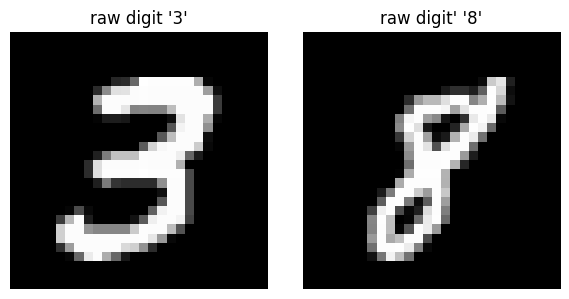

sum of raw pixesl - img_3: 35867.0, img_8: 27106.0


In [5]:
# cell 5 - visual inspection before any computation
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img_3, cmap='gray'); axes[0].set_title("raw digit '3'"); axes[0].axis('off')
axes[1].imshow(img_8, cmap='gray'); axes[1].set_title("raw digit' '8'"); axes[1].axis('off')
plt.tight_layout(); plt.show()

print(f"sum of raw pixesl - img_3: {img_3.sum():.1f}, img_8: {img_8.sum():.1f}")

In [6]:
# cell 6 - normalize to discrete probability measure μ (mew = m) and ν (nu = v)
def to_measure(img: np.ndarray) -> np.ndarray:
    """
    converts a 2d grayscale image to a discrete probability measure.
    flattens to a 1d vector and normalizes so that sum = 1.
    each entry m[i] is the mass at pixel location i.
    raises if image is blank (sum = 0).
    """
    flat = img.flatten().astype(np.float64)
    total = flat.sum()
    if total == 0:
        raise ValueError("image is blank - cannot normalize a zero measure")
    return flat/total

m = to_measure(img_3) # shape (28*28 = 784, )
v = to_measure(img_8)

print(f"m shape: {m.shape}; v shape: {v.shape}")
print(f"m sum: {m.sum():.6f}") # must be exactly 1
print(f"v sum: {v.sum():.6f}") # must be exactly 1
print(f"m min: {m.min():.6f}") # must be >= 0 to ensure no negative pixels present
print(f"v min: {v.min():.6f}") # must be >= 0 to ensure no negative pixels present

m shape: (784,); v shape: (784,)
m sum: 1.000000
v sum: 1.000000
m min: 0.000000
v min: 0.000000


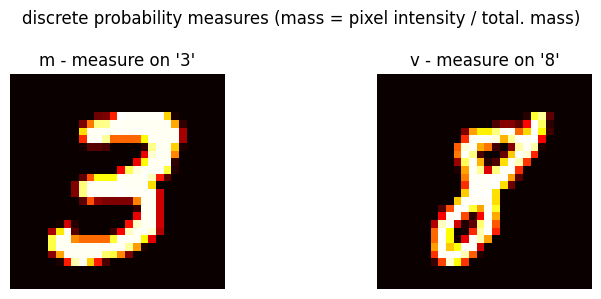

In [7]:
# cell 7 - visualize the measure as 2d mass distributions
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(m.reshape(28, 28), cmap='hot'); axes[0].set_title("m - measure on '3'"); axes[0].axis('off')
axes[1].imshow(v.reshape(28, 28), cmap='hot'); axes[1].set_title("v - measure on '8'"); axes[1].axis('off')
plt.suptitle("discrete probability measures (mass = pixel intensity / total. mass)")
plt.tight_layout(); plt.show()

# sanity: both should look identical to the raw images in structure
# the 'hot' colormap makes the mass interpretation more vivid

In [8]:
# cell 8 - construct pixel coordinates for a 28x28 grid
coords = np.array([[i // 28, i % 28] for i in range(784)], dtype=np.float64) # shape (784, 2)

print(coords)
print(f"\ncoords shape: {coords.shape}")
print(f"first pixel (top-left): {coords[0]}") # expect [0, 0]
print(f"last pixel (bottom-right): {coords[783]}") # expect [27, 27]
print(f"pixel 28 (start of row 1): {coords[28]}") # expect[1,0]

[[ 0.  0.]
 [ 0.  1.]
 [ 0.  2.]
 ...
 [27. 25.]
 [27. 26.]
 [27. 27.]]

coords shape: (784, 2)
first pixel (top-left): [0. 0.]
last pixel (bottom-right): [27. 27.]
pixel 28 (start of row 1): [1. 0.]


In [9]:
# cell 9 - compute the squared euclidean cost matrix
def compute_cost_matrix(coords: np.ndarray) -> np.ndarray:
    """
    constructs the gound cost matrix C of shape (n, n).
    C[i, j] = squared euclidean distance between pixel positions i and j.
    this is the w_2 ground cost: moving mass from i to j costs ||x_i - x_j||^2
    """
    diff = coords[:, np.newaxis, :] - coords[np.newaxis, :, :] # (784, 784, 2)
    C = np.sum(diff ** 2, axis=-1) # (784, 784)
    return C

C = compute_cost_matrix(coords)
print(f"C shape: {C.shape}")
print(f"C diagonal: {C[0, 0]}, {C[1, 1]} - expect 0.0 (no cost to stay)")
print(f"C[0, 27]: {C[0, 27]:.1f} - expect {27**2:.1f} (row0, col 0 -> col 27)")
print(f"C[0, 783]: {C[0, 783]:.1f} - expect {(27**2 + 27**2):.1f} (top-left -> botton-right)")
print(f"C symmetric: {np.allclose(C, C.T)}")

C shape: (784, 784)
C diagonal: 0.0, 0.0 - expect 0.0 (no cost to stay)
C[0, 27]: 729.0 - expect 729.0 (row0, col 0 -> col 27)
C[0, 783]: 1458.0 - expect 1458.0 (top-left -> botton-right)
C symmetric: True


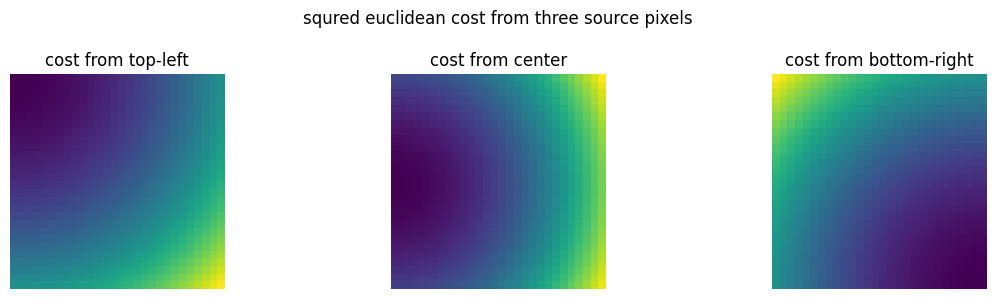

In [10]:
# cell 10 - visualize cost from a single source pixel
fix, axes = plt.subplots(1, 3, figsize=(12, 3))
source_pixels = [0, 392, 783] # top-left, center, bottom-right
titles = ["cost from top-left", "cost from center", "cost from bottom-right"]

for ax, src, title in zip(axes, source_pixels, titles):
    ax.imshow(C[src].reshape(28, 28), cmap='viridis')
    ax.set_title(title)
    ax.axis('off')

plt.suptitle("squred euclidean cost from three source pixels")
plt.tight_layout(); plt.show()

In [11]:
# cell 11 — define log-domain sinkhorn
def sinkhorn_log(mu, nu, C, epsilon, n_iter=1000, tol=1e-9):
    """
    sinkhorn-knopp in log-domain using LSE for numerical stability.
    operates on log-potentials f, g (= epsilon * log u, epsilon * log v).
    returns: transport plan pi (n, n), potentials f and g.
    """
    log_mu = np.log(m + 1e-300) # guard against log(0) on zero-mass pixels
    log_nu = np.log(v + 1e-300) # guard against log(0) on zero-mass pixels

    f = np.zeros(len(m))
    g = np.zeros(len(v))

    for _ in range(n_iter):
        f_prev = f.copy()
        f = epsilon * log_mu - epsilon * scipy_logsumexp((g[np.newaxis, :] - C) / epsilon, axis=1)
        g = epsilon * log_nu - epsilon * scipy_logsumexp((f[:, np.newaxis] - C) / epsilon, axis=0)
        if np.max(np.abs(f - f_prev)) < tol: # stops the loop early if the values stop changing, meaning the solution has "converged"
            break

    # construct transport plan: log π_ij = (f_i + g_j - C_ij) / ε
    log_pi = (f[:, np.newaxis] + g[np.newaxis, :] - C) / epsilon
    pi = np.exp(log_pi)
    return pi, f, g

In [12]:
# cell 12 — run sinkhorn and verify marginal constraints
C_norm = C / C.max()
epsilon = 0.01

pi, f, g = sinkhorn_log(m, v, C_norm, epsilon=epsilon, n_iter=1000)

print(f"pi shape: {pi.shape}")
print(f"pi non-negative: {(pi >= 0).all()}")
print(f"pi row sums ≈ mew: {np.allclose(pi.sum(axis=1), m, atol=1e-6)}")
print(f"pi col sums ≈ nu: {np.allclose(pi.sum(axis=0), v, atol=1e-6)}")
print(f"pi total mass: {pi.sum():.10f}")

pi shape: (784, 784)
pi non-negative: True
pi row sums ≈ mew: True
pi col sums ≈ nu: True
pi total mass: 1.0000000000


In [13]:
# cell 13 - compute primal cost <C, pi>
primal_cost = np.sum(C_norm * pi)
print(f"primal cost <C, pi>: {primal_cost:.6f}")

primal cost <C, pi>: 0.009719


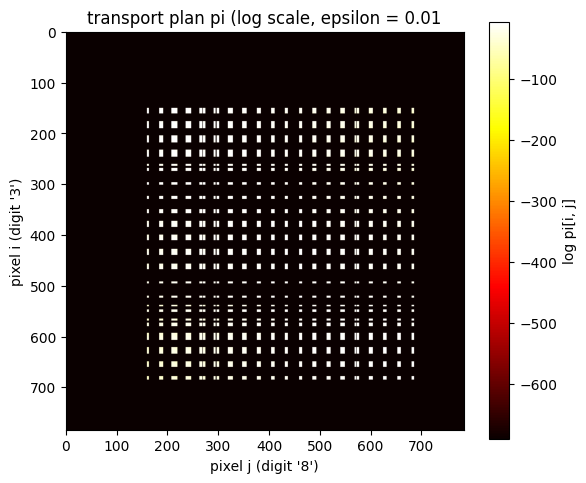

In [14]:
# cell 14 -visualize transport plan (log scale used since most entries are near zero)
plt.figure(figsize=(6, 5))
plt.imshow(np.log(pi + 1e-300), cmap='hot')
plt.colorbar(label='log pi[i, j]')
plt.title(f"transport plan pi (log scale, epsilon = {epsilon}")
plt.xlabel("pixel j (digit '8')"); plt.ylabel("pixel i (digit '3')")
plt.tight_layout(); plt.show()

In [15]:
# cell 15 - effect of epsilon: run at three values and compare primal cost
for eps in [1.0, 0.1, 0.01]:
    pi_eps, _, _ = sinkhorn_log(m, v, C_norm, epsilon=eps, n_iter=1000)
    cost = np.sum(C_norm * pi_eps)
    print(f"epsilon={eps:.2f} -> primal cost: {cost:.6f} | "
          f"marginals OK: {np.allclose(pi_eps.sum(axis=1), m, atol=1e-5)}")

epsilon=1.00 -> primal cost: 0.063129 | marginals OK: True
epsilon=0.10 -> primal cost: 0.040568 | marginals OK: True
epsilon=0.01 -> primal cost: 0.009719 | marginals OK: True


In [16]:
# cell 16 - extract dual potentials directly from sinkhorn output
# f and g are already the regularized kantorovich potentials
phi = f # dual potential for m (mew)
psi = g # dual potential for v (nu)

print(f"phi shape: {phi.shape}, range: [{phi.min():.4f}, {phi.max():.4f}]")
print(f"psi shape: {psi.shape}, range: [{psi.min():.4f}, {psi.max():.4f}]")

phi shape: (784,), range: [-6.9562, -0.0750]
psi shape: (784,), range: [-6.8568, 0.0220]


In [17]:
# cell 17 - compute primal objective: <C_norm, pi> - epsilon * H(pi)
H_pi = -np.sum(pi * np.log(pi + 1e-300)) # entropy of transport plan (shannon entropy)
primal_obj = np.sum(C_norm * pi) - epsilon * H_pi

print(f"primal cost <C_norm, pi>: {np.sum(C_norm * pi):.8f}")
print(f"entropy H(pi): {H_pi:.8f}")
print(f"regularized primal objective: {primal_obj:.8f}")

primal cost <C_norm, pi>: 0.00971915
entropy H(pi): 8.94968029
regularized primal objective: -0.07977765


In [18]:
# cell 18 - compute dual objective: <phi, mu> + <psi, nu>
dual_obj = np.dot(phi, m) + np.dot(psi, v)

print(f"dual objective <phi, mu> + <psi, nu>: {dual_obj:.8f}")
print(f"primal objective: {primal_obj:.8f}")
print(f"duality gap: {abs(primal_obj - dual_obj):.2e}")
print(f"strong duality holds (tol=1e-6): {np.isclose(primal_obj, dual_obj, atol=1e-6)}")

dual objective <phi, mu> + <psi, nu>: -0.07977765
primal objective: -0.07977765
duality gap: 1.79e-10
strong duality holds (tol=1e-6): True


In [19]:
# cell 19 - verify complementary slackness condition visually
# for optimal pi: pi[i, j] > 0only where phi[i] + psi[j] ~ C_norm[i, j]
slack = C_norm - (phi[:, np.newaxis] + psi[np.newaxis, :]) # should be >= 0 everywhere
weighted_slack = slack * pi # should be ~ 0 wherever pi has mass

print(f"slack min (expect >= 0): {slack.min():.6f}")
print(f"weighted slack max: {weighted_slack.max():.2e}")
print(f"weighted slack mean: {weighted_slack.mean():.2e}")

slack min (expect >= 0): 0.074001
weighted slack max: 4.52e-05
weighted slack mean: 1.46e-07


In [20]:
# cell 20 - compute displacement interpolation frames
def displacement_interpolation(pi, coords, timesteps):
    """
    compute wasserstein geodesic frames via displacement interpolation.
    each frame t is the pushforward of pi under T_t(x, y) = (1-t)x + ty.
    mass at (i, j) in pi moves to position (1-t)*coords[i] + t*coords[j].
    returns array of shape (len(timesteps), 28, 28).
    """
    frames = []
    for t in timesteps: # loops through the animation timeline (from 0.0 to 1.0)
        frame = np.zeros(784) # creates a blank 28x28 canvas (flattened) for the current time t
        for i in range(784): 
            if pi[i].sum() < 1e-12: # skips source pixels that have no ink so that no time is wasted moving black pixel
                continue
            #interpolated positions for all j: shape (784, 2)
            interp_coords = (1 - t) * coords[i] + t * coords # (784, 2)
            # round to nearest pixel
            rows = np.clip(np.round(interp_coords[:, 0]).astype(int), 0, 27)
            cols = np.clip(np.round(interp_coords[:, 1]).astype(int), 0, 27)
            target_indices = rows * 28 + cols # maps 2d coordinates back to the 1d index (0–783) since we need a single number to know where to put the ink
            np.add.at(frame, target_indices, pi[i]) # np.add.at is used instead of standard indexing because multiple source pixels might "land" on the same target pixel at the same time; this ensures their mass is summed together rather than overwritten
        frames.append(frame.reshape(28, 28)) # takes the finished 784-vector, turns it back into a 28x28 image, and stores it
    return np.array(frames)

timesteps = np.linspace(0, 1, 10)
frames_wasserstein = displacement_interpolation(pi, coords, timesteps)

print(f"frames shape: {frames_wasserstein.shape}") # expect (10, 28, 28)
print(f"frames sum (expect ~1.0 each):")
print(np.round([f.sum() for f in frames_wasserstein], 6))

frames shape: (10, 28, 28)
frames sum (expect ~1.0 each):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [21]:
# cell 21 - verify boundary conditions
print(f"t = 0 frame ~ mu reshaped: {np.allclose(frames_wasserstein[0], m.reshape(28, 28), atol=1e-5)}")
print(f"t = 1 frame ~ nu reshaped: {np.allclose(frames_wasserstein[-1], v.reshape(28, 28), atol=1e-5)}")

t = 0 frame ~ mu reshaped: True
t = 1 frame ~ nu reshaped: True


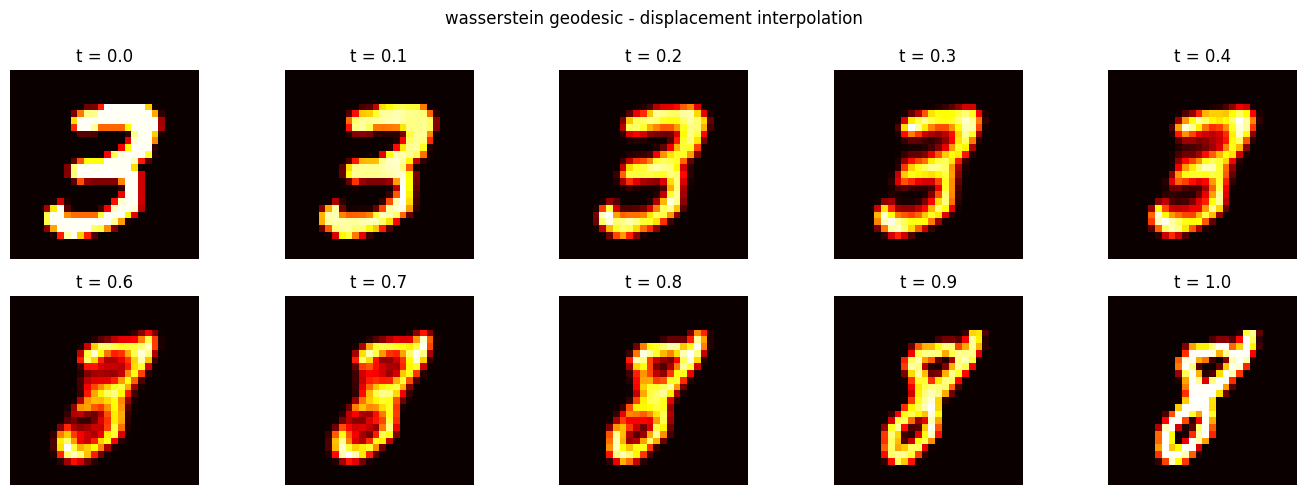

In [22]:
# cell 22 - inspect intermediate frames visually
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
for idx, (ax, t) in enumerate(zip(axes.flat, timesteps)):
    ax.imshow(frames_wasserstein[idx], cmap='hot')
    ax.set_title(f"t = {t:.1f}")
    ax.axis('off')
plt.suptitle("wasserstein geodesic - displacement interpolation")
plt.tight_layout(); plt.show()

In [23]:
# cell 23 - naive pixel blending baseline
frames_blending = np.array([
    (1-t) * m.reshape(28, 28) + t * v.reshape(28, 28)
    for t in timesteps
])

print(f"frames shape: {frames_blending.shape}") # verifies that the total ink remains 1.0
print(f"frame sums: {np.round([f.sum() for f in frames_blending], 6)}")

frames shape: (10, 28, 28)
frame sums: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


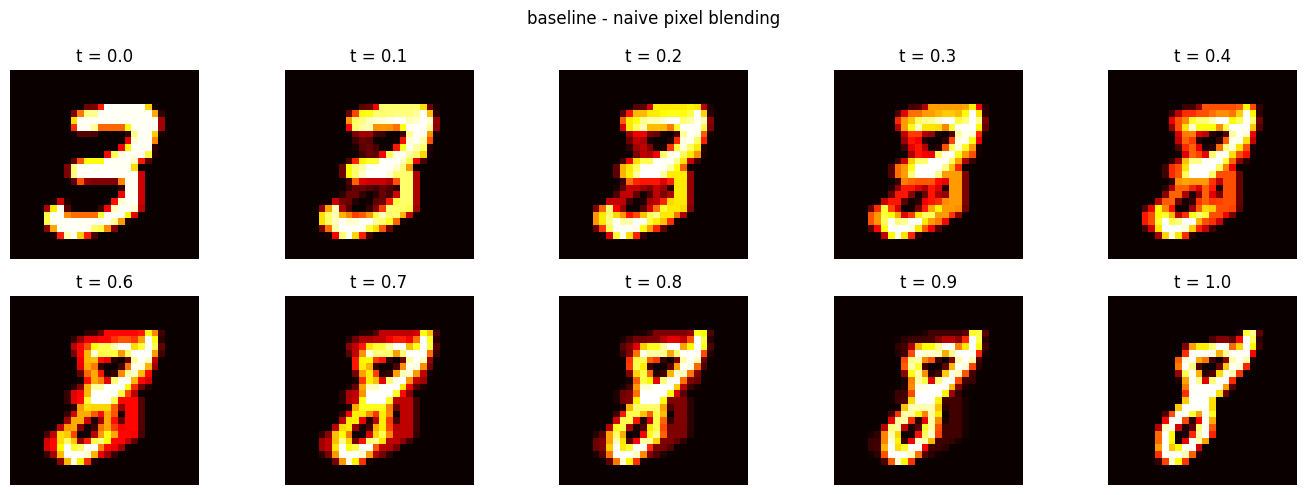

In [24]:
# cell 24 - visual inspection
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
for idx, (ax, t) in enumerate(zip(axes.flat, timesteps)):
    ax.imshow(frames_blending[idx], cmap='hot')
    ax.set_title(f"t = {t:.1f}")
    ax.axis('off')
plt.suptitle("baseline - naive pixel blending")
plt.tight_layout(); plt.show()

In [25]:
# cell 25 - build side-by-side animation
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

im_w = axes[0].imshow(frames_wasserstein[0], cmap='hot', vmin=0, vmax=max(frames_wasserstein.max(), frames_blending.max()))
im_b = axes[1].imshow(frames_blending[0], cmap='hot', vmin=0, vmax=max(frames_wasserstein.max(), frames_blending.max()))

axes[0].set_title("wassersteing geodesic", fontsize=12)
axes[1].set_title("pixel blending", fontsize=12)

for ax in axes: ax.axis('off')

time_text = fig.suptitle("t = 0.0", fontsize=13, y=1)
fig.tight_layout()

def update(frame_idx):
    im_w.set_data(frames_wasserstein[frame_idx])
    im_b.set_data(frames_blending[frame_idx])
    time_text.set_text(f"t = {timesteps[frame_idx]:.1f}")
    return im_w, im_b, time_text

ani = animation.FuncAnimation(fig, update, frames=len(timesteps), interval=300, blit=False)
plt.close()

In [26]:
# cell 26 - display inline
HTML(ani.to_jshtml())

In [27]:
# cell 27 - save as gif and individual png frames
# save gif
writer = animation.PillowWriter(fps=4)
ani.save("morphing.gif", writer=writer)
print("saved: morphing.gif")

# save individual frames
for idx, t, in enumerate(timesteps):
    fig_f, axes_f = plt.subplots(1, 2, figsize=(8, 4))
    axes_f[0].imshow(frames_wasserstein[idx], cmap='hot')
    axes_f[0].set_title("wassersteing geodesic")
    axes_f[0].axis('off')
    
    axes_f[1].imshow(frames_blending[idx], cmap='hot')
    axes_f[1].set_title("pixel blending")
    axes_f[1].axis('off')
    
    fig_f.suptitle(f"t = {t:.1f}")
    fig_f.savefig(f"frames/frame_{idx:02d}_t{t:.1f}.png", dpi=150, bbox_inches='tight')
    plt.close(fig_f)

print(f"saved {len(timesteps)} png frames to ./frames/")

saved: morphing.gif
saved 10 png frames to ./frames/
